# Raspberry Pi Pico – Beginner Notebook

This notebook is a simple beginner-friendly introduction to controlling a **Raspberry Pi Pico** from a Jupyter notebook over **USB serial** with `mpremote`.

You can use it to:
- check whether the Pico is connected
- run simple MicroPython code on the Pico
- blink the built-in LED
- measure the internal temperature sensor
- test PWM, buttons, and analog input

## Important idea

There are **two kinds of Python** in this notebook:

1. **Notebook Python**  
   This runs on your computer.

2. **Pico MicroPython**  
   This runs on the Raspberry Pi Pico.

Whenever you see a long string called `code = ''' ... '''`, that part is sent to the Pico and executed there.


## 1. Import tools and define a helper function

This cell does three things:

- imports Python tools for plotting and communicating
- defines `run_on_pico(...)`
- shows which serial ports `mpremote` can see

Run this first.


In [8]:

import matplotlib.pyplot as plt
import subprocess
import sys

def run_on_pico(code: str, port: str = "auto", exec_timeout_s: float = 20.0):
    cmd = [sys.executable, "-m", "mpremote", "connect", port, "exec", code]
    proc = subprocess.run(cmd, capture_output=True, text=True, timeout=exec_timeout_s)
    return proc.stdout.strip(), proc.stderr.strip()

cmd = [sys.executable, "-m", "mpremote", "connect", "list"]
ports = subprocess.run(cmd, capture_output=True, text=True, timeout=10)

print("Detected ports/devices:")
print(ports.stdout if ports.stdout else "(no devices listed)")
if ports.stderr:
    print("Errors:")
    print(ports.stderr)


Detected ports/devices:
COM3 E6605481DB296137 2e8a:0005 Microsoft None



## 2. Choose the port and test the connection

Usually `port = "auto"` is enough.

This sends a very small command to the Pico:

```python
print("hello from pico")
```

If you get output back, the connection works.


In [9]:

port = "auto"
print("Using port:", port)

out, err = run_on_pico("print('hello from pico')", port=port)
print("STDOUT:\n", out)
print("STDERR:\n", err)


Using port: auto
STDOUT:
 hello from pico
STDERR:
 


## 3. Blink the built-in LED

This is the classic first microcontroller test.

The code below:
- imports `Pin` from `machine`
- selects the built-in LED
- toggles it on and off several times

Why the `try` block?  
Some boards use `"LED"` as the LED name, others use pin `25`.


In [10]:

code = '''
from machine import Pin
from utime import sleep

print("Starting LED blink test...")

try:
    led = Pin("LED", Pin.OUT)
except Exception:
    led = Pin(25, Pin.OUT)

for _ in range(30):
    led.toggle()
    sleep(0.3)

print("Done.")
'''

out, err = run_on_pico(code, port=port, exec_timeout_s=20)
print("STDOUT:\n", out)
print("STDERR:\n", err)


STDOUT:
 Starting LED blink test...
Done.
STDERR:
 


## 4. Measure the internal temperature sensor

The RP2040 has an internal temperature sensor that can be read through `ADC(4)`.

This example:
- records several values
- prints time, raw ADC value, and temperature
- converts the printed text into lists
- plots the temperature in the notebook

The sensor is useful for learning, but it is **not a precision room thermometer**.


STDERR:
 
STDOUT:
t_s,raw,temp_c
0.00,14067,25.64
0.50,14051,26.11
1.00,14051,26.11
1.50,14051,26.11
2.00,14051,26.11
2.50,14067,25.64
3.00,14051,26.11
3.50,14067,25.64
4.00,14051,26.11
4.50,14051,26.11
5.00,14067,25.64


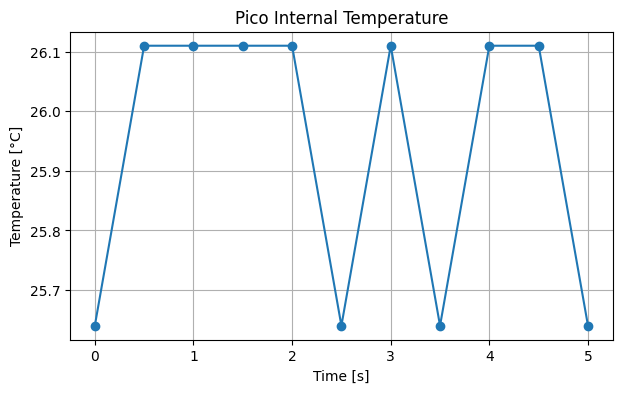

In [15]:

duration_s = 5
sample_interval_s = 0.5
sample_count = int(duration_s / sample_interval_s) + 1

code = f'''
from machine import ADC
from utime import sleep

sensor = ADC(4)
interval_s = {sample_interval_s}
sample_count = {sample_count}

print("t_s,raw,temp_c")
for i in range(sample_count):
    raw = sensor.read_u16()
    voltage = raw * 3.3 / 65535
    temp_c = 27 - (voltage - 0.706) / 0.001721
    t_s = i * interval_s
    print(f"{{t_s:.2f}},{{raw}},{{temp_c:.2f}}")
    sleep(interval_s)
'''

out, err = run_on_pico(code, port=port, exec_timeout_s=20)
print("STDERR:\n", err)

times = []
temps = []

lines = out.splitlines()
print("STDOUT:")
for line in lines:
    print(line)

for line in lines[1:]:
    t_s, raw, temp_c = line.split(",")
    times.append(float(t_s))
    temps.append(float(temp_c))

plt.figure(figsize=(7, 4))
plt.plot(times, temps, marker="o")
plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.title("Pico Internal Temperature")
plt.grid(True)
plt.show()


## 5. PWM example: dim an LED

PWM means **Pulse Width Modulation**.  
It is often used to:
- dim LEDs
- control motor speed
- create simple analog-like output behavior

### Wiring
- connect an LED with resistor to **GPIO 15**
- connect the other side to **GND**

This example increases brightness and then decreases it again.


In [12]:

# code = '''
# from machine import Pin, PWM
#from utime import sleep

# led = PWM(Pin(15))
# led.freq(1000)

# print("Fading LED on GPIO 15")

# for _ in range(2):
#     for duty in range(0, 65535, 2500):
#         led.duty_u16(duty)
#         sleep(0.03)
#     for duty in range(65535, 0, -2500):
#         led.duty_u16(duty)
#         sleep(0.03)

# led.duty_u16(0)
# print("Done.")
# '''

# out, err = run_on_pico(code, port=port, exec_timeout_s=20)
# print("STDOUT:\n", out)
# print("STDERR:\n", err)


## 6. Button input with internal pull-up resistor

This is a standard way to connect a button.

### Wiring
- one side of the button to **GPIO 14**
- other side of the button to **GND**

Because we use `Pin.PULL_UP`:
- not pressed → value is usually `1`
- pressed → value becomes `0`


In [13]:

# code = '''
# from machine import Pin
# from utime import sleep

# button = Pin(14, Pin.IN, Pin.PULL_UP)

# print("Reading button on GPIO 14")
# for _ in range(20):
#     print(button.value())
#     sleep(0.2)
# '''

# out, err = run_on_pico(code, port=port, exec_timeout_s=20)
# print("STDOUT:\n", out)
# print("STDERR:\n", err)


## 7. Analog input with a potentiometer

A potentiometer is a variable resistor.  
It is a very common beginner component because it gives a changing analog voltage.

### Wiring
- one outer pin → **3.3 V**
- other outer pin → **GND**
- middle pin → **GPIO 26** (ADC0)

This example measures:
- raw ADC value
- calculated voltage

Then it plots the voltage.


In [14]:

# duration_s = 5
# sample_interval_s = 0.25
# sample_count = int(duration_s / sample_interval_s) + 1

# code = f'''
# from machine import ADC
# from utime import sleep

# pot = ADC(26)
# interval_s = {sample_interval_s}
# sample_count = {sample_count}

# print("t_s,raw,voltage")
# for i in range(sample_count):
#     raw = pot.read_u16()
#     voltage = raw * 3.3 / 65535
#     print(f"{{i * interval_s:.2f}},{{raw}},{{voltage:.3f}}")
#     sleep(interval_s)
# '''

# out, err = run_on_pico(code, port=port, exec_timeout_s=20)
# print("STDERR:\n", err)

# times = []
# voltages = []

# lines = out.splitlines()
# print("STDOUT:")
# for line in lines:
#     print(line)

# for line in lines[1:]:
#     t_s, raw, voltage = line.split(",")
#     times.append(float(t_s))
#     voltages.append(float(voltage))

# plt.figure(figsize=(7, 4))
# plt.plot(times, voltages, marker="o")
# plt.xlabel("Time [s]")
# plt.ylabel("Voltage [V]")
# plt.title("Potentiometer on GPIO 26")
# plt.grid(True)
# plt.show()


## 8. Very small standalone Pico examples

These are short examples you can also copy directly into a `.py` file on the Pico.

### Fast blink
```python
from machine import Pin
from time import sleep

led = Pin("LED", Pin.OUT)

while True:
    led.toggle()
    sleep(0.2)
```

### Read potentiometer
```python
from machine import ADC
from time import sleep

pot = ADC(26)

while True:
    raw = pot.read_u16()
    voltage = raw * 3.3 / 65535
    print(raw, voltage)
    sleep(0.5)
```


## Troubleshooting

### If the Pico is not detected
- check the USB cable
- some USB cables only provide power, not data
- make sure MicroPython is installed on the Pico
- try unplugging and reconnecting the board

### If `mpremote` fails
Install it in your Python environment:
```bash
pip install mpremote
```

### If plots are empty
That usually means the Pico did not return readable lines, so first inspect `STDERR` and `STDOUT`.
